# Exploratory Data Analysis

## Shane Waldron

## Kaggle Playground Series

## GSB 545

In [12]:
# Importing libaries for EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importing the dataset
df = pd.read_csv("data/train.csv")
df.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [13]:
# Checking data types 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

In [ ]:
# Removing the id column as it is not useful for modeling or EDA
df.drop("id", axis=1, inplace=True)

In [15]:
# Splitting up columns into categorical and numerical
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

In [16]:
# Checking for missing values
df.isnull().sum()

Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

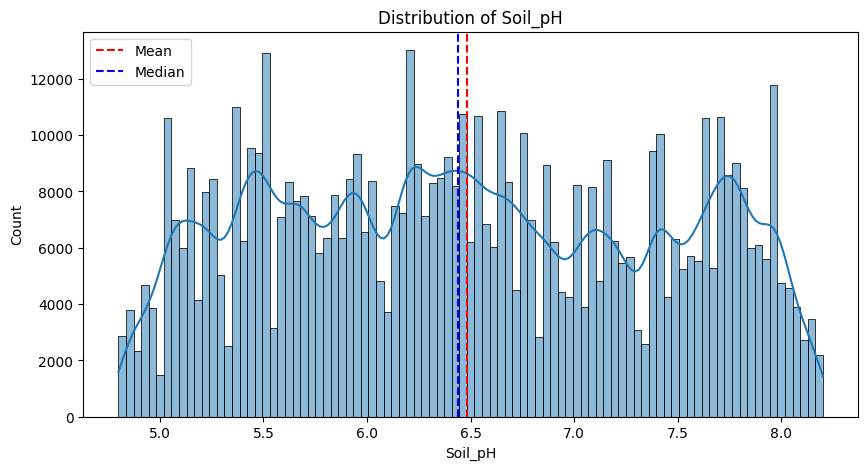

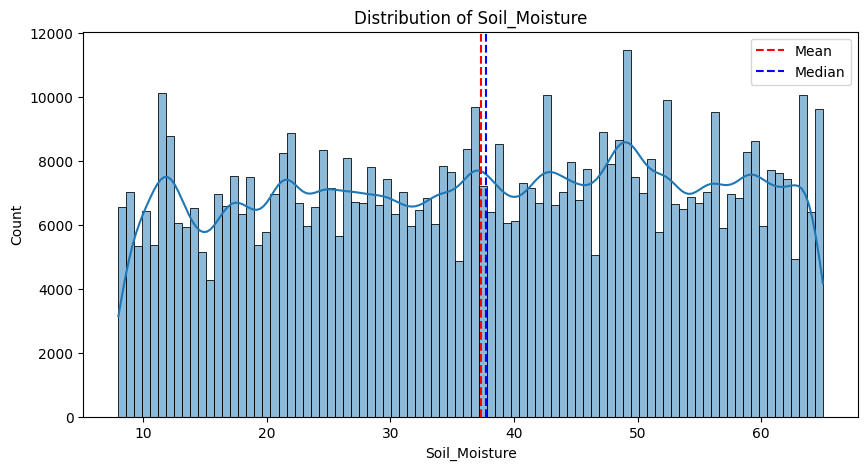

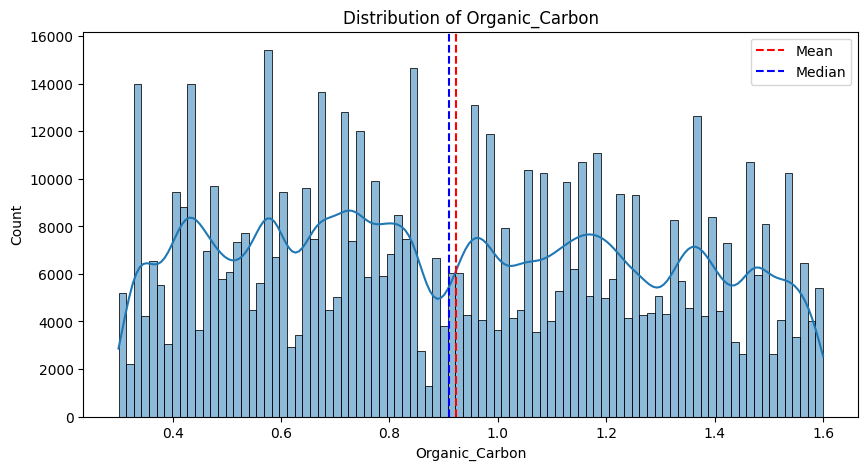

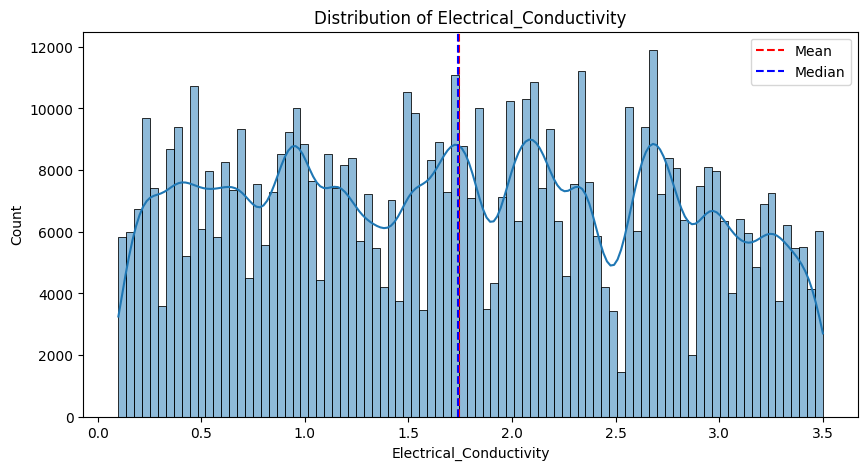

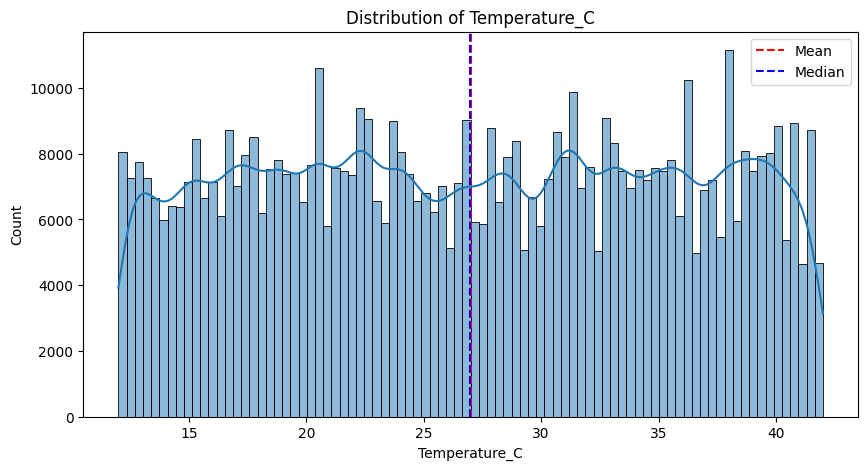

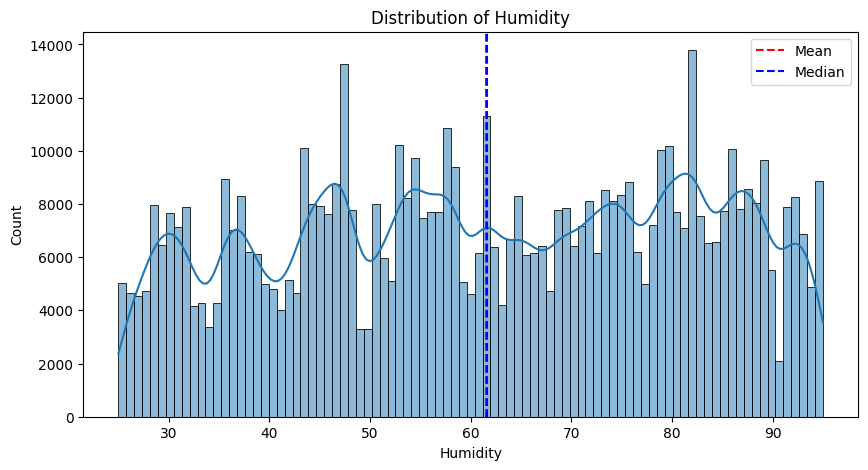

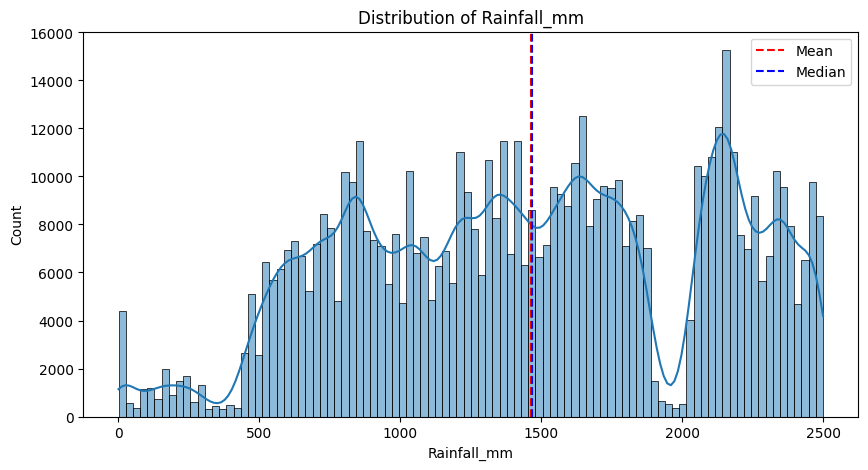

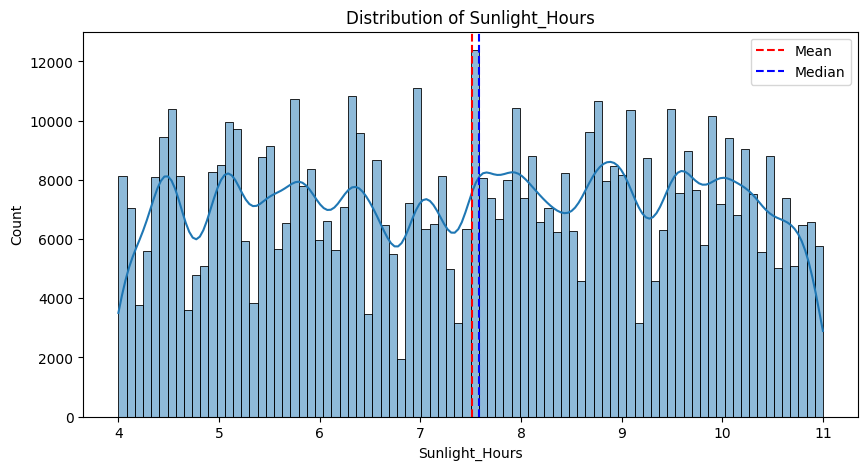

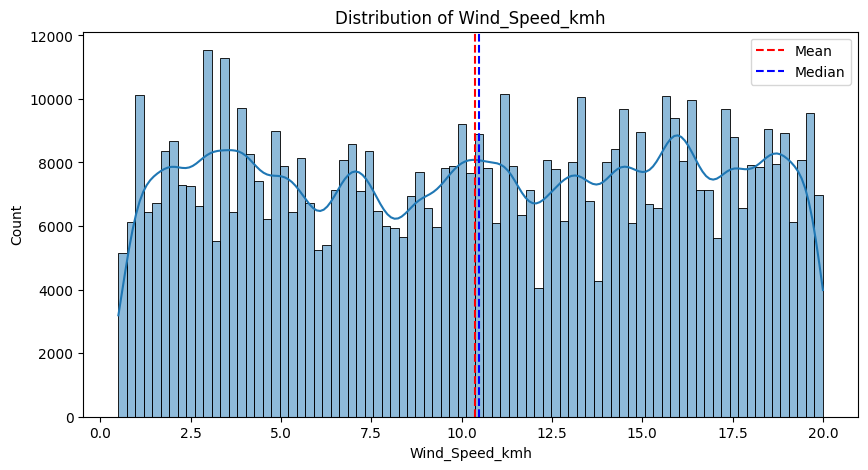

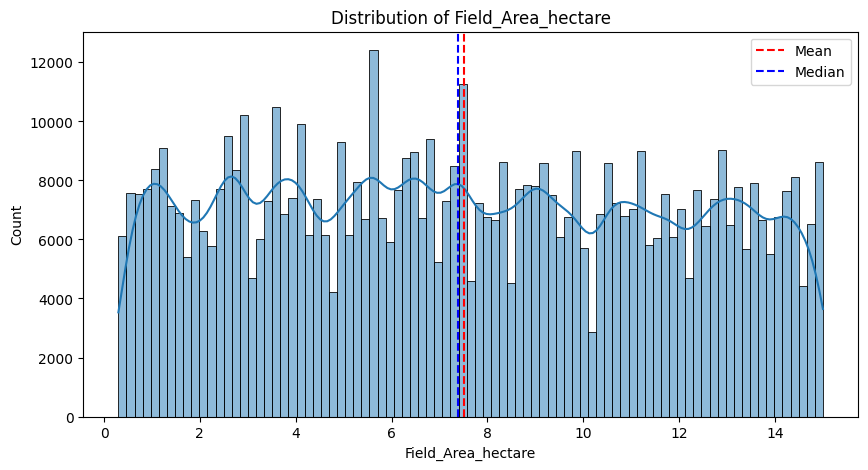

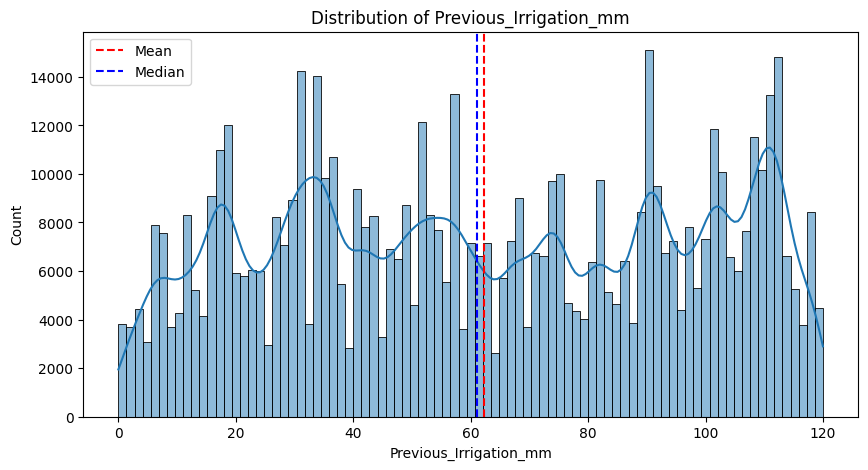

In [22]:
# Checking distribution of numerical variables
for col in numerical_cols:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    # Adding means and medians to the plot
    plt.axvline(df[col].mean(), color='red', linestyle='--', label='Mean')
    plt.axvline(df[col].median(), color='blue', linestyle='--', label='Median')
    plt.legend()
    plt.show()

### Insights from Numerical Column Distributions

- The numerical features are all well spread across their ranges, and the means and medians are very close. The distributions are balanced and not heavily skewed.
- Some variables such as `Soil_Moisture`, `Temperature_C`, `Humidity`, `Rainfall_mm`, `Sunlight_Hours`, `Wind_Speed_kmh`, and `Previous_Irrigation_mm` have wider ranges compared to features such as `Soil_pH`, `Organic_Carbon`, and `Electrical_Conductivity` which have smaller ranges and thus tighter bands.
- Does not seem like there are any extreme outliers that need to be dealt with before modeling.
- The numerical variables look clean and model-friendly.

In [20]:
# Summary of the categorical variables
for col in categorical_cols:
    print(f"Value counts for {col}:")
    print(df[col].value_counts(normalize=True))
    print("\n")

Value counts for Soil_Type:
Soil_Type
Sandy    0.264300
Clay     0.251540
Loamy    0.248341
Silt     0.235819
Name: proportion, dtype: float64


Value counts for Crop_Type:
Crop_Type
Sugarcane    0.172873
Rice         0.169360
Cotton       0.166103
Maize        0.165514
Wheat        0.163500
Potato       0.162649
Name: proportion, dtype: float64


Value counts for Crop_Growth_Stage:
Crop_Growth_Stage
Harvest       0.266173
Flowering     0.250100
Vegetative    0.249597
Sowing        0.234130
Name: proportion, dtype: float64


Value counts for Season:
Season
Kharif    0.343748
Rabi      0.330211
Zaid      0.326041
Name: proportion, dtype: float64


Value counts for Irrigation_Type:
Irrigation_Type
Canal        0.256986
Sprinkler    0.256190
Rainfed      0.246995
Drip         0.239829
Name: proportion, dtype: float64


Value counts for Water_Source:
Water_Source
Reservoir      0.258721
River          0.253681
Groundwater    0.244690
Rainwater      0.242908
Name: proportion, dtype: float64

### Categorical Variable Distributions
For the most part, the categorical variables have relatively even distributions across all the columns besides the target variable which is Irrigation Need.

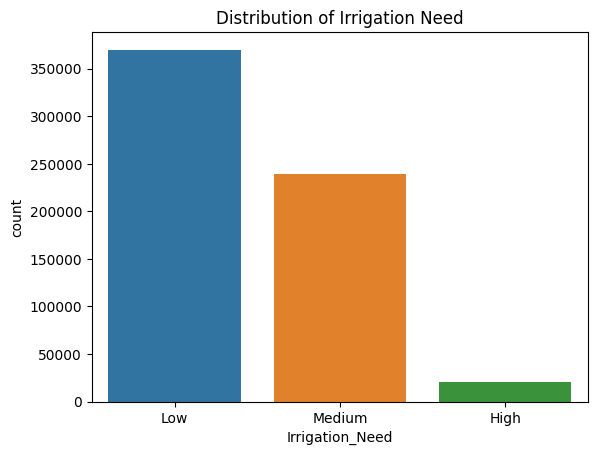

In [21]:
# Looking at the distribution of the target variable
sns.countplot(x="Irrigation_Need", data=df, hue = 'Irrigation_Need')
plt.title("Distribution of Irrigation Need")
plt.show()

### Numerical Value Distributions based on Irrigation Need

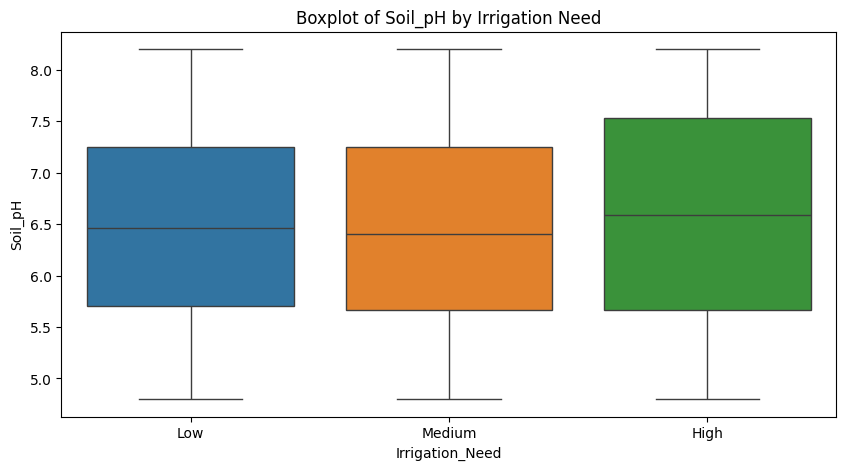

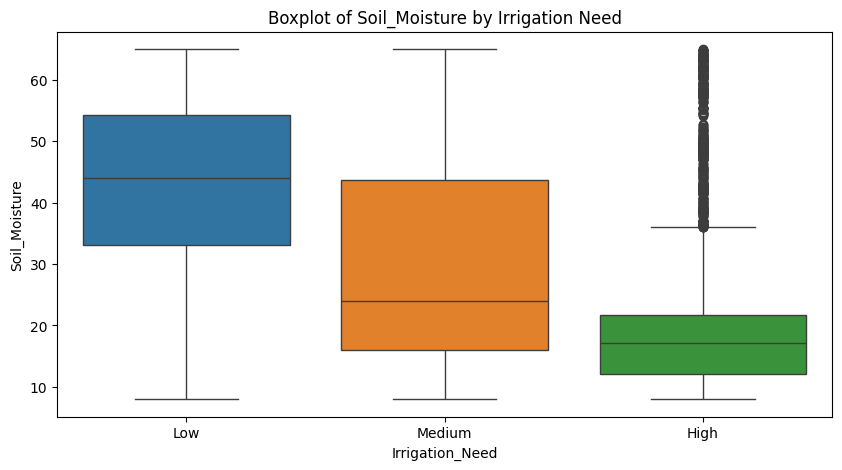

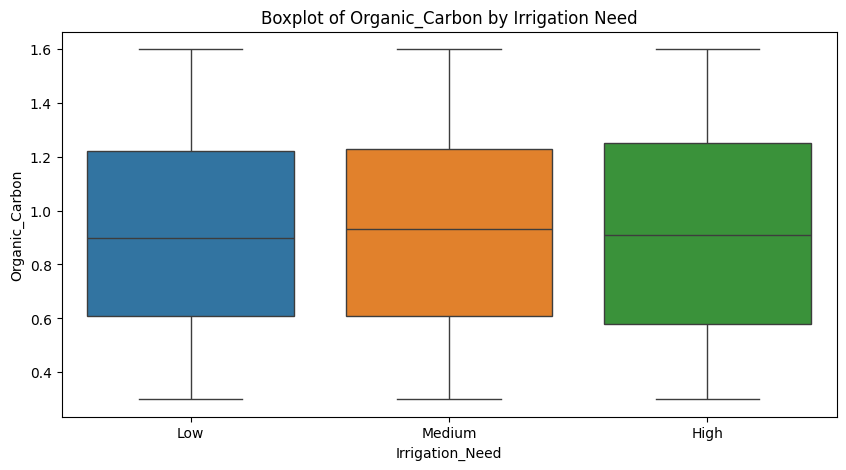

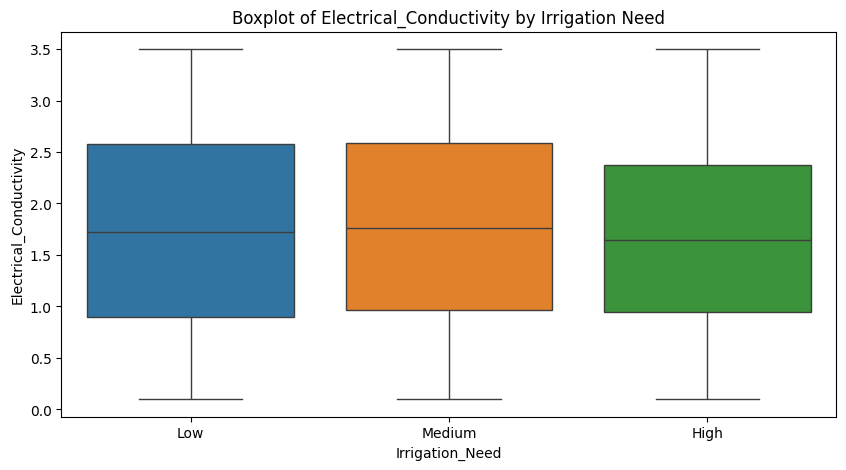

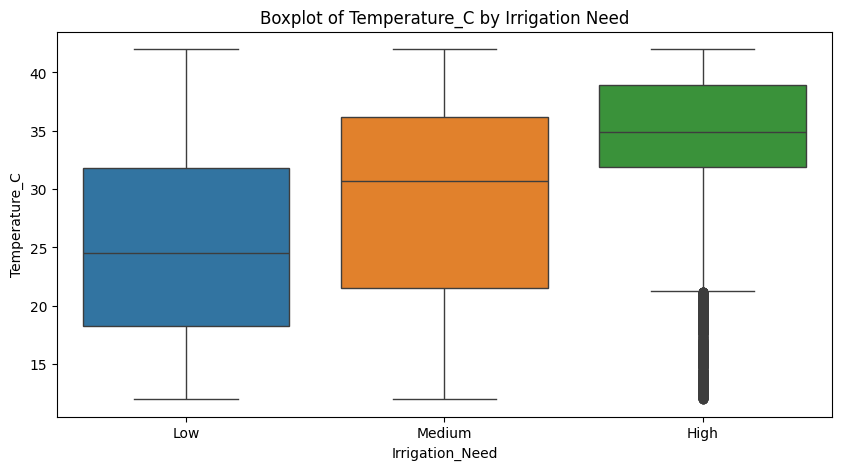

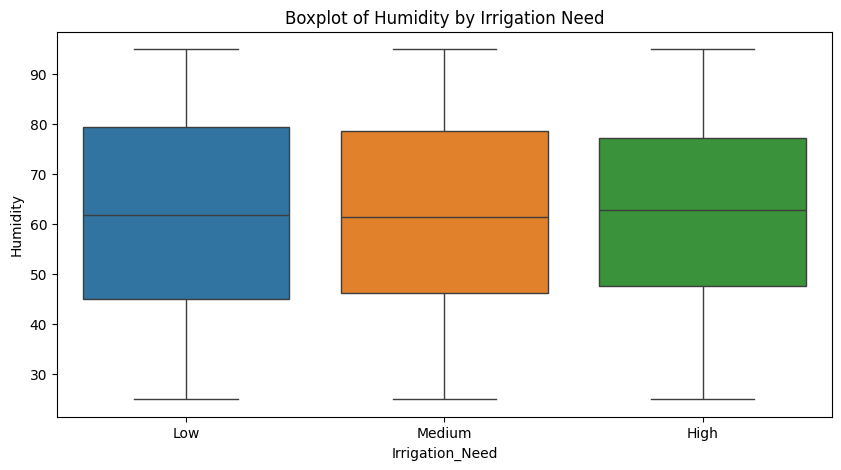

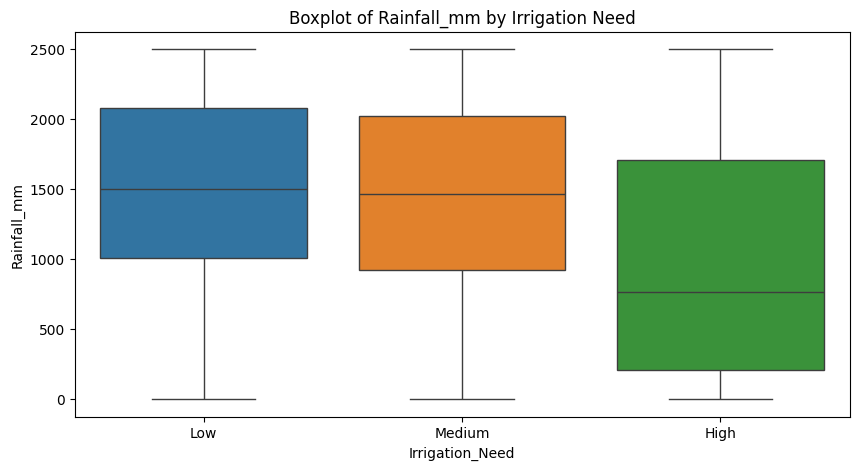

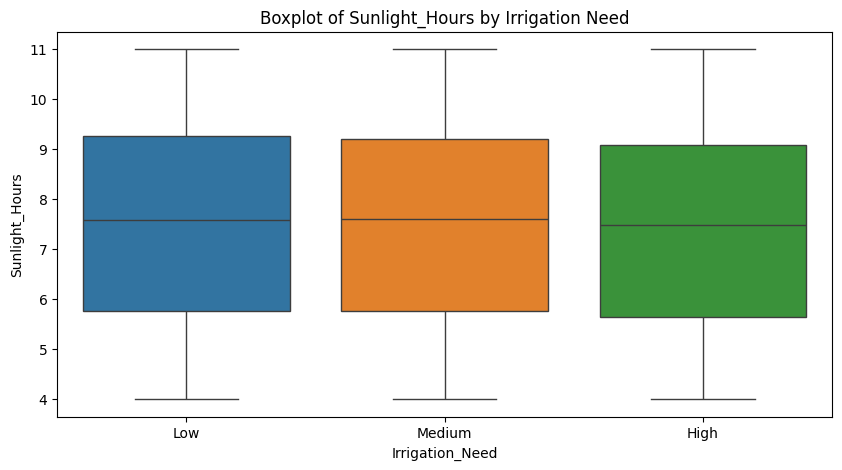

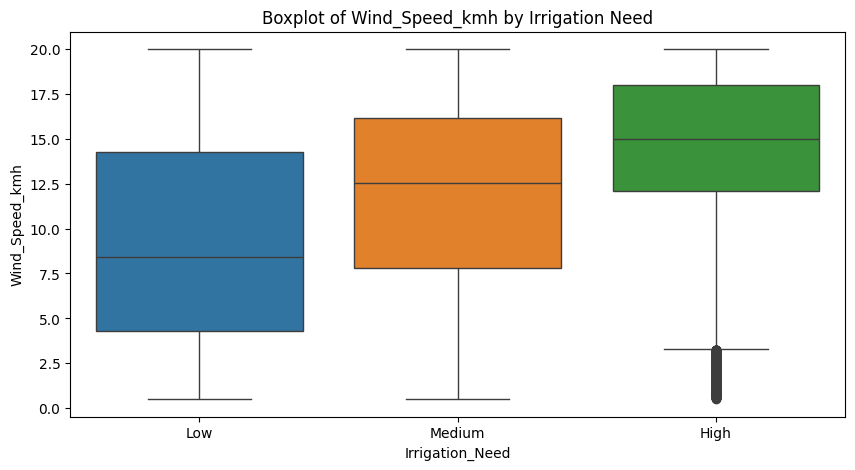

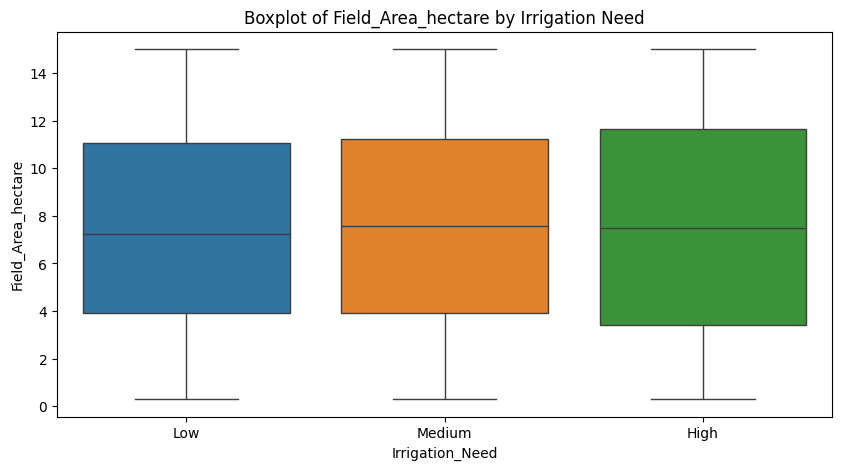

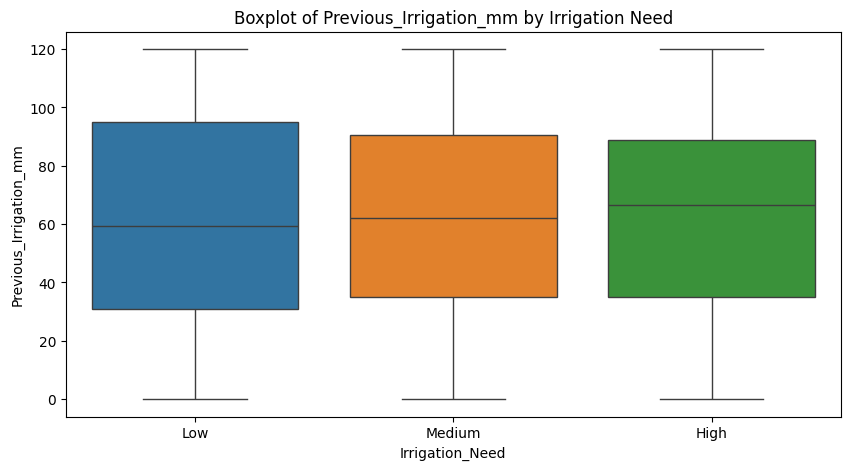

In [ ]:
# Looking at the distribution of the numerical variables based on the target variable value
for col in numerical_cols:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x="Irrigation_Need", y=col, data=df, hue = 'Irrigation_Need')
    plt.title(f"Boxplot of {col} by Irrigation Need")
    plt.show()

Based on the boxplots, the following numerical features seem the most important for predicting irrigation need based on their uneven spreads at different levels of irrigation need.

- `Soil_Moisture`
- `Temperature_C`
- `Wind_Speed_kmh`
- `Rainfall_mm`

### Checking Categorical Variable Spread by Irrigation Need

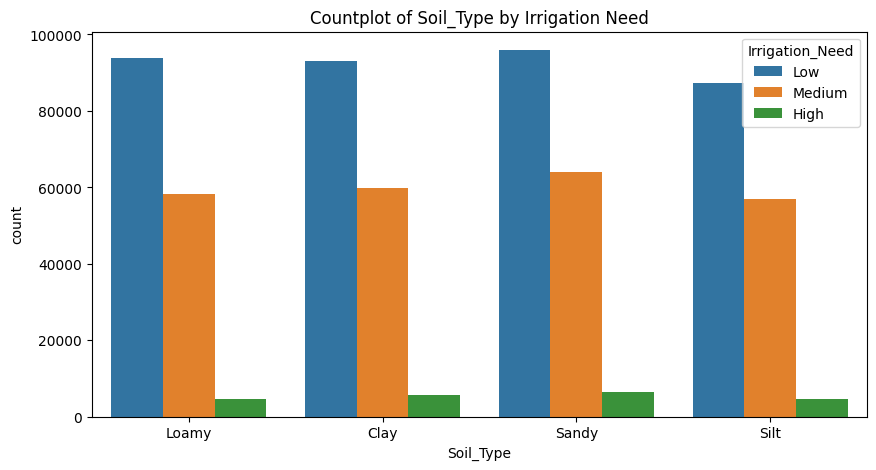

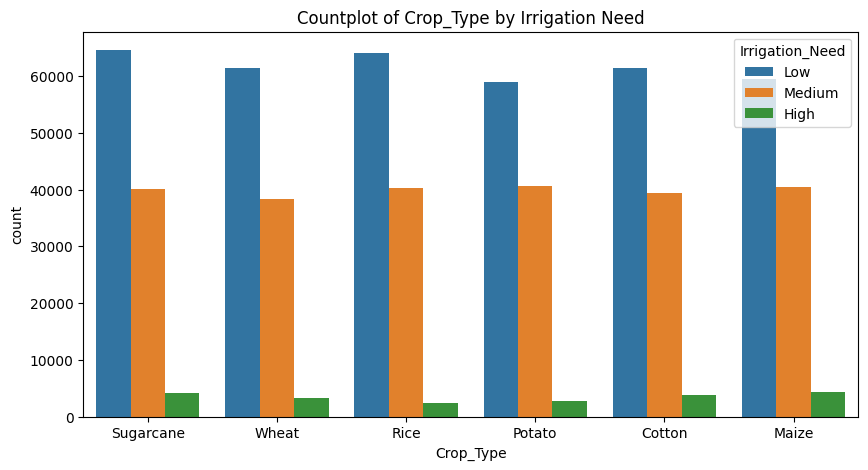

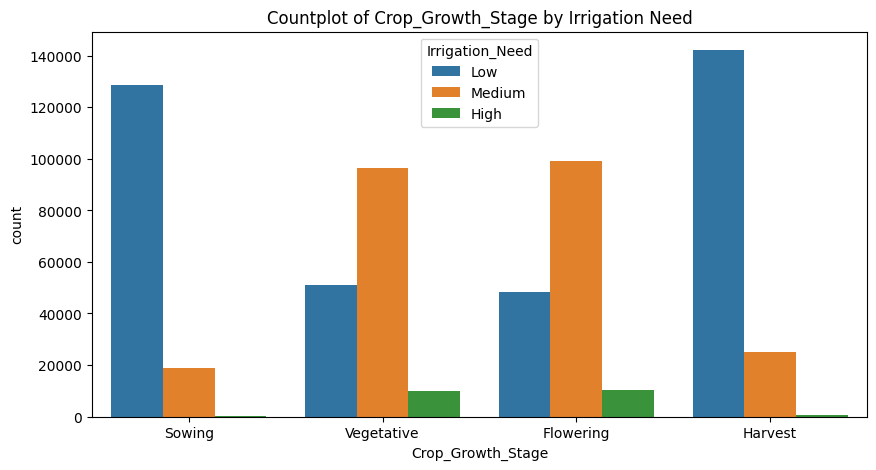

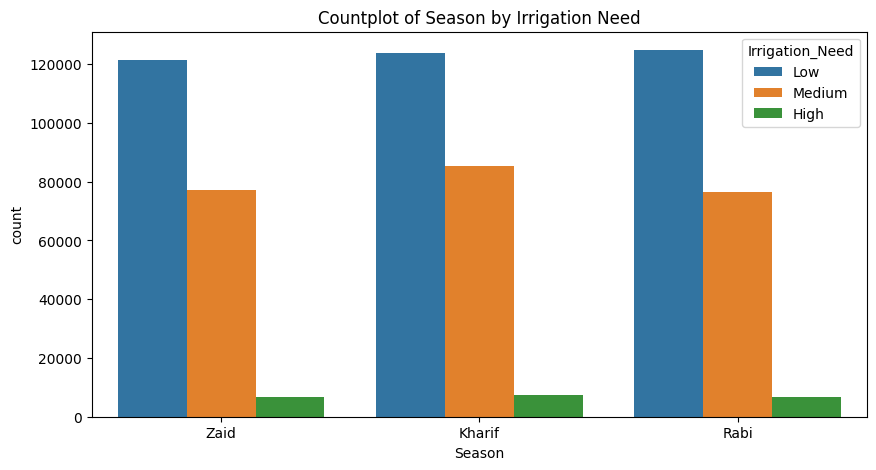

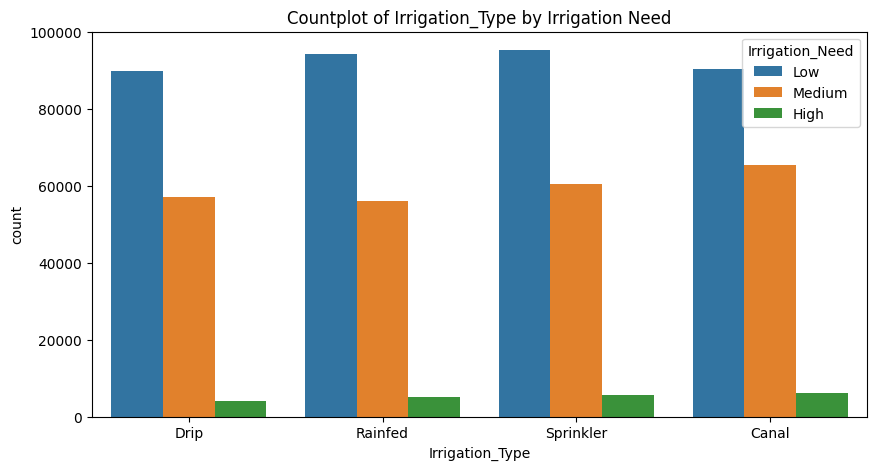

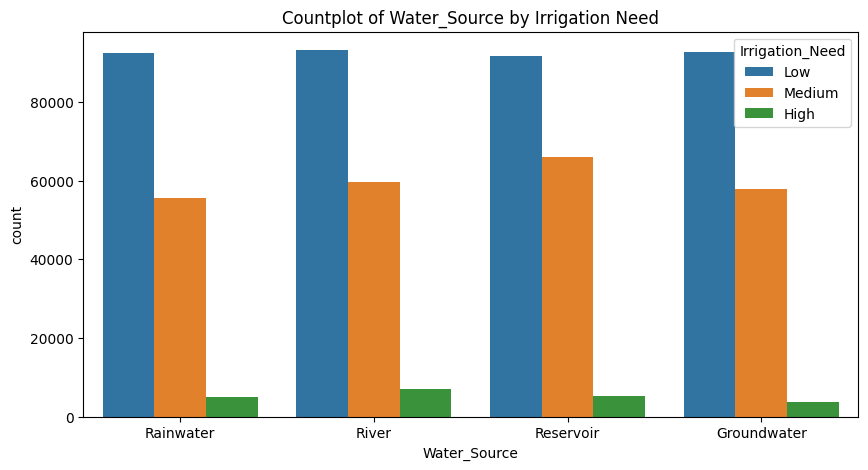

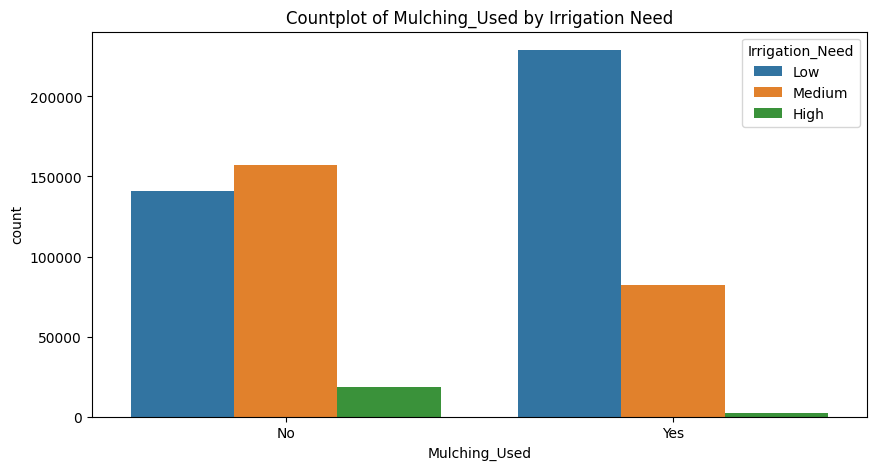

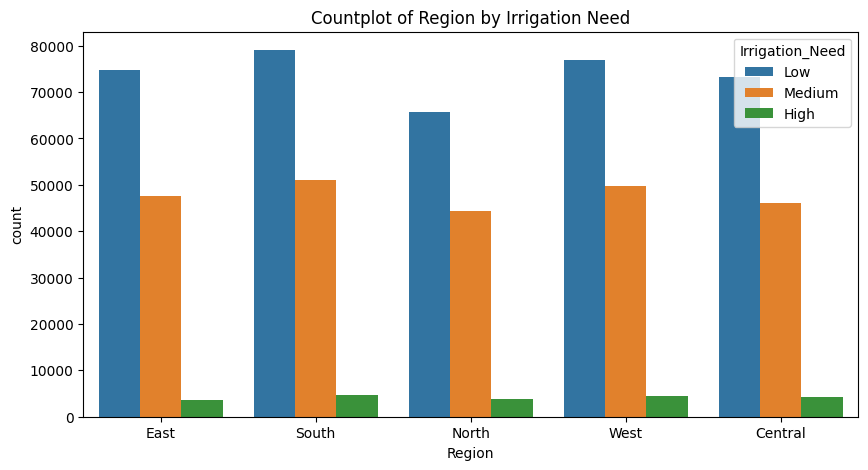

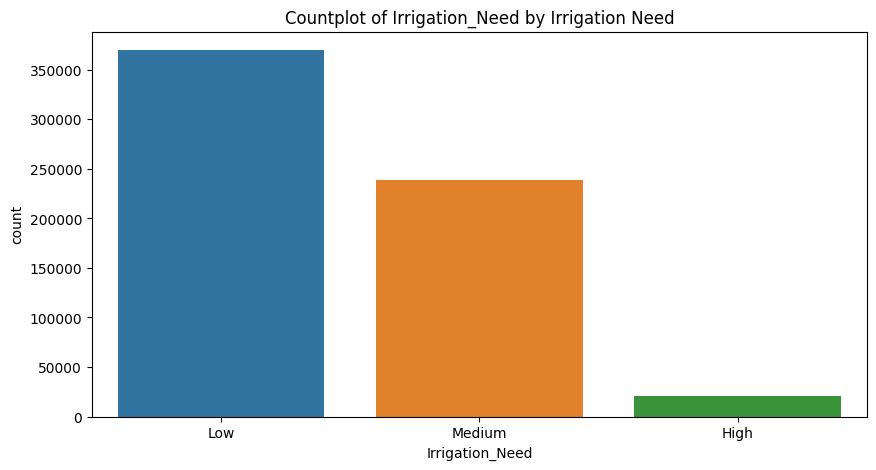

In [27]:
# Checking categorical variables by target variable
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=col, data=df, hue="Irrigation_Need")
    plt.title(f"Countplot of {col} by Irrigation Need")
    plt.show()


The categorical features that seem important for identifying irrigation need are
- `Mulching_Used`
- `Crop_Growth_Stage`

### Summary

Overall, the features appear consistent, well-behaved, and suitable for modeling, with little evidence of severe skewness or problematic outliers.